In [8]:
from modeller import *

env = Environ()
aln = Alignment(env)

# Template 1
mdl = Model(env, file='../pde4d_swissmodel', model_segment=('FIRST:A','LAST:A'))
aln.append_model(mdl, align_codes='pde4d_swissmodel', atom_files='../pde4d_swissmodel.pdb')

# Template 2
mdl2 = Model(env, file='../3G45', model_segment=('247:A','658:A'))
aln.append_model(mdl2, align_codes='pde4b_3g45', atom_files='../3G45.pdb')

# Alinha as duas estruturas entre si
aln.salign()

# Adiciona a sequência completa do alvo
aln.append(file='../pde4b_target.ali', align_codes='pde4b_target')

# Alinha a sequência ao alinhamento estrutural
aln.align2d(max_gap_length=50)

aln.write(file='pde4d-pde4b.ali', alignment_format='PIR')
aln.write(file='pde4d-pde4b.pap', alignment_format='PAP')

readlinef__W> File: ../3G45.pdb, Line: 5
              Modeller will only read the first 80 characters of this line.


SALIGN_____> adding the next group to the alignment; iteration    1
mkapsa__637W> No residue topology library is in memory.
              Better radii would be used if topology.read() is called first.
iup2crm_280W> No topology library in memory or assigning a BLK residue.
              Default CHARMM atom type assigned:  N -->  N
              This message is written only for the first such atom.

Pairwise dynamic programming alignment (ALIGN2D):
  Residue-residue metric   : $(LIB)/as1.sim.mat
  Diagonal                 :          100
  Overhang                 :            0
  Maximal gap length       :           50
  Local alignment          :            F
  MATRIX_OFFSET (local aln):       0.0000
  FIX_OFFSETS              :      0.0    -1.0    -2.0    -3.0    -4.0
  N_SUBOPT                 :            0
  SUBOPT_OFFSET            :       0.0000
  Alignment block 

In [23]:
from modeller import *
from modeller.automodel import *

env = Environ()
env.rand_seed = -1

a = AutoModel(env,
              alnfile='pde4d-pde4b.ali',
              knowns=('pde4d_swissmodel', 'pde4b_3g45'),
              sequence='pde4b_target',
              assess_methods=(assess.DOPE, assess.GA341))

a.template_weights = (0.2, 1.0)
a.md_level = refine.slow
a.repeat_optimization = 3
a.starting_model = 1
a.ending_model = 15

a.make()

openf___224_> Open           $(LIB)/restyp.lib
openf___224_> Open           ${MODINSTALL10v8}/modlib/restyp_cif.lib
openf___224_> Open           ${MODINSTALL10v8}/modlib/resgrp.lib
rdresgr_266_> Number of residue groups:        2
openf___224_> Open           ${MODINSTALL10v8}/modlib/sstruc.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     62583763   61116.957    59.685

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     62584291   61117.473    59.685
openf___224_> Open           ${MODINSTALL10v8}/modlib/resdih.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     62632891   61164.934    59.731
rdrdih__263_> Number of dihedral angle types         :        9
              Maximal number of dihedral angle optima:        3
              Dihedral angle names                   :  Alph Phi Psi Omeg chi1 chi2 chi3 chi4 chi5
openf___224_> Open           ${MODINSTALL10v8}/modlib/radii.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,Mi

In [24]:
from modeller import *
from modeller.scripts import complete_pdb
import glob
import os

log.verbose()
env = Environ()
env.libs.topology.read(file='$(LIB)/top_heav.lib')
env.libs.parameters.read(file='$(LIB)/par.lib')

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/'
#modelling_dir = r'C:\Users\vitor\Documents\usp\usp-masters\data\structure_prediction\homology_modelling'
model_files = sorted(glob.glob(os.path.join(modelling_dir, '*.B9999*.pdb')))

for i, model_path in enumerate(model_files, start=1):
    profile_file = os.path.join(modelling_dir, f'modelo_{i}.profile')
    
    print(f'calc DOPE model {i}: {os.path.basename(model_path)}')
    
    mdl = complete_pdb(env, model_path)
    s = Selection(mdl)
    s.assess_dope(output='ENERGY_PROFILE NO_REPORT', file=profile_file,
                  normalize_profile=True, smoothing_window=15)


openf___224_> Open           $(LIB)/restyp.lib
openf___224_> Open           ${MODINSTALL10v8}/modlib/restyp_cif.lib
openf___224_> Open           ${MODINSTALL10v8}/modlib/resgrp.lib
rdresgr_266_> Number of residue groups:        2
openf___224_> Open           ${MODINSTALL10v8}/modlib/sstruc.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     80899327   79003.250    77.152

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     80899855   79003.766    77.152
openf___224_> Open           ${MODINSTALL10v8}/modlib/resdih.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     80948455   79051.227    77.198
rdrdih__263_> Number of dihedral angle types         :        9
              Maximal number of dihedral angle optima:        3
              Dihedral angle names                   :  Alph Phi Psi Omeg chi1 chi2 chi3 chi4 chi5
openf___224_> Open           ${MODINSTALL10v8}/modlib/radii.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,Mi

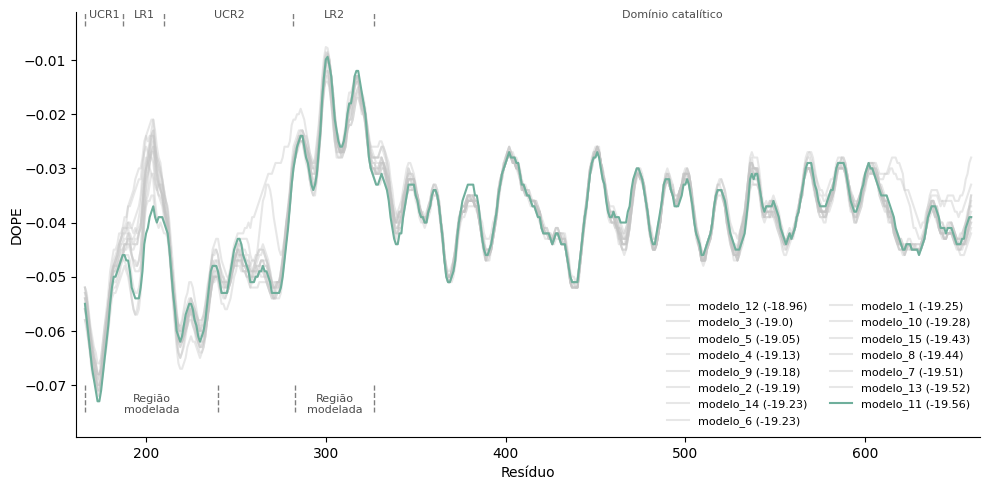

In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import re

#modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/'
profiles_with_sum = []
profile_files = sorted(glob.glob(os.path.join(modelling_dir, 'model*.profile')))
for profile_path in profile_files:
    total_sum = None
    with open(profile_path, 'r') as f:
        for line in f:
            match = re.search(r'The sum of all numbers in the file:\s+([-\d.]+)', line)
            if match:
                total_sum = float(match.group(1))
                break
    
    profiles_with_sum.append((profile_path, total_sum))

# ordenar do menor DOPE para o maior
profiles_with_sum.sort(key=lambda x: x[1], reverse=True)

plt.figure(figsize=(10, 5))

cinza = "#c4c4c4"
colors = [
    cinza,cinza,cinza,cinza,cinza,cinza,cinza,cinza,cinza,cinza,cinza,cinza,cinza,cinza,   
    '#6FAF9C'        
]

all_dope = []
for i, (profile_path, total_sum) in enumerate(profiles_with_sum):
    name = os.path.basename(profile_path).replace('.profile', '')
    df = pd.read_csv(profile_path, sep='\s+', comment='#', header=None)
    residues = df[0] + 165
    dope=df[df.columns[-1]]
    all_dope.extend(dope.tolist())
    label = f'{name} ({round(total_sum, 2)})'    

    if i == 14:
        alpha = 1
    else:
        alpha = 0.4

    plt.plot(residues, dope, label=label, color=colors[i], alpha=alpha)

# Scaling
margin = (max(all_dope) - min(all_dope)) * 0.1
plt.ylim(min(all_dope) - margin, max(all_dope) + margin)

plt.xlabel('Resíduo')
plt.ylabel('DOPE', labelpad=0)

plt.title('')
plt.legend(fontsize=8,frameon=False, ncol=2)
ax = plt.gca()

y_top = 0 
y_cut = y_top - (y_top - min(all_dope)) * 0.05  # altura onde a linha para

ax.vlines(166, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(187, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(210, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(282, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(327, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)

ax.vlines(166, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(240, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(283, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(327, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)

y_text = max(all_dope) - (max(all_dope) - min(all_dope)) 
ax.text((166+187)/2, y_text * 0.01,
        'UCR1',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7, color='black')

ax.text((188+210)/2, y_text* 0.01,
        'LR1',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7, color='black')

ax.text((211+282)/2, y_text* 0.01,
        'UCR2',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7, color='black')

ax.text((283+327)/2, y_text* 0.01,
        'LR2',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7, color='black')

ax.text((328+658)/2, y_text* 0.01,
        'Domínio catalítico',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7, color='black')

ax.text((166+240)/2, y_text *0.98,
        'Região\nmodelada',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7, color='black')

ax.text((283+327)/2, y_text* 0.98,
        'Região\nmodelada',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7, color='black')

plt.margins(x=0.01)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(modelling_dir, 'dope_profiles.png'), dpi=150)
plt.show() 

In [8]:
from modeller import *
from modeller.automodel import *

class MyLoop(LoopModel):
    def select_loop_atoms(self):
        return Selection(
            self.residue_range('166:A', '187:A'), #ucr1
            self.residue_range('188:A', '210:A'), #lr1
            self.residue_range('211:A', '282:A'), #ucr2
            self.residue_range('283:A', '327:A'), #lr2
        )

env = Environ()
env.rand_seed = -1

a = MyLoop(env,
           alnfile='pde4d-pde4b.ali',
           knowns=('pde4d_swissmodel', 'pde4b_3g45'),
           sequence='pde4b_target',
           inimodel='pde4b_target.B99990008.pdb',
           assess_methods=assess.DOPE)

a.loop.starting_model = 1
a.loop.ending_model = 5
a.loop.md_level = refine.very_slow  # bom para loop

a.make()

openf___224_> Open           $(LIB)/restyp.lib
openf___224_> Open           ${MODINSTALL10v7}/modlib/restyp_cif.lib
openf___224_> Open           ${MODINSTALL10v7}/modlib/resgrp.lib
rdresgr_266_> Number of residue groups:        2
openf___224_> Open           ${MODINSTALL10v7}/modlib/sstruc.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     31965859   31216.660    30.485

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     31966387   31217.176    30.486
openf___224_> Open           ${MODINSTALL10v7}/modlib/resdih.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:     32014987   31264.637    30.532
rdrdih__263_> Number of dihedral angle types         :        9
              Maximal number of dihedral angle optima:        3
              Dihedral angle names                   :  Alph Phi Psi Omeg chi1 chi2 chi3 chi4 chi5
openf___224_> Open           ${MODINSTALL10v7}/modlib/radii.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,Mi

In [4]:
from modeller import *
from modeller.scripts import complete_pdb
import glob
import os

log.verbose()
env = Environ()
env.libs.topology.read(file='$(LIB)/top_heav.lib')
env.libs.parameters.read(file='$(LIB)/par.lib')

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/'
#odelling_dir = r'C:\Users\vitor\Documents\usp\usp-masters\data\structure_prediction\homology_modelling'
model_files = sorted(glob.glob(os.path.join(modelling_dir, '*BL*.pdb')))


                         MODELLER 10.8, 2025/11/04, r13157

     PROTEIN STRUCTURE MODELLING BY SATISFACTION OF SPATIAL RESTRAINTS


                     Copyright(c) 1989-2025 Andrej Sali
                            All Rights Reserved

                             Written by A. Sali
                               with help from
              B. Webb, M.S. Madhusudhan, M-Y. Shen, G.Q. Dong,
          M.A. Marti-Renom, N. Eswar, F. Alber, M. Topf, B. Oliva,
             A. Fiser, R. Sanchez, B. Yerkovich, A. Badretdinov,
                     F. Melo, J.P. Overington, E. Feyfant
                 University of California, San Francisco, USA
                    Rockefeller University, New York, USA
                      Harvard University, Cambridge, USA
                   Imperial Cancer Research Fund, London, UK
              Birkbeck College, University of London, London, UK


Kind, OS, HostName, Kernel, Processor: 4, Linux gbi017039525 6.8.0-106-generic x86_64
Date and time of compil

In [14]:
model_files

['C:\\Users\\vitor\\Documents\\usp\\usp-masters\\data\\structure_prediction\\homology_modelling\\pde4b_target.BL00010001.pdb',
 'C:\\Users\\vitor\\Documents\\usp\\usp-masters\\data\\structure_prediction\\homology_modelling\\pde4b_target.BL00020001.pdb',
 'C:\\Users\\vitor\\Documents\\usp\\usp-masters\\data\\structure_prediction\\homology_modelling\\pde4b_target.BL00030001.pdb',
 'C:\\Users\\vitor\\Documents\\usp\\usp-masters\\data\\structure_prediction\\homology_modelling\\pde4b_target.BL00040001.pdb',
 'C:\\Users\\vitor\\Documents\\usp\\usp-masters\\data\\structure_prediction\\homology_modelling\\pde4b_target.BL00050001.pdb']

In [5]:
for i, model_path in enumerate(model_files, start=1):

    profile_file = os.path.join(modelling_dir, f'loopmodel{i}.profile')
    print(model_path)
    print(profile_file)
    #print(f'calc DOPE model {i}: {os.path.basename(model_path)}')
    
    #mdl = complete_pdb(env, model_path)
    #s = Selection(mdl)
    #s.assess_dope(output='ENERGY_PROFILE NO_REPORT', file=profile_file,
    #              normalize_profile=True, smoothing_window=15)


/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/pde4b_target.BL00010001.pdb
/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/loopmodel1.profile
/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/pde4b_target.BL00020001.pdb
/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/loopmodel2.profile
/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/pde4b_target.BL00030001.pdb
/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/loopmodel3.profile
/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/pde4b_target.BL00040001.pdb
/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/loopmodel4.profile
/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/pde4b_targe

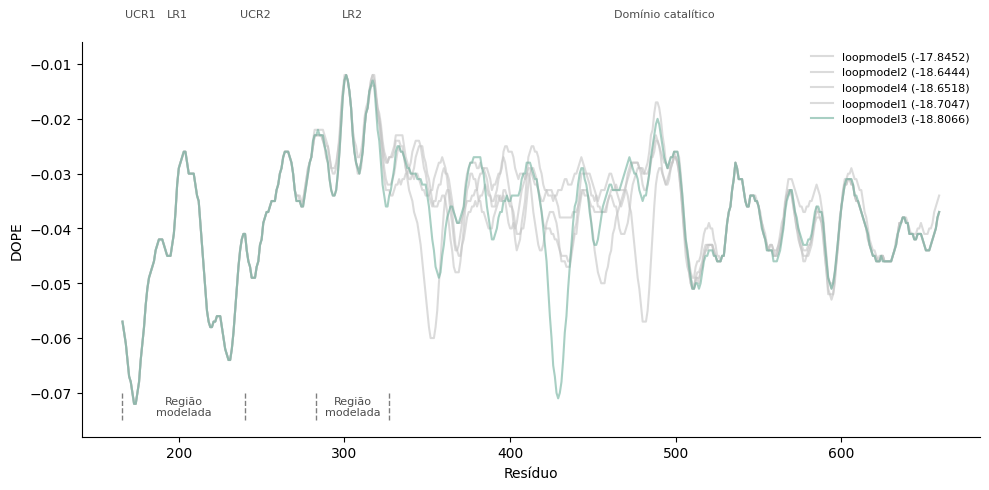

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import re

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/'
profiles_with_sum = []
profile_files = sorted(glob.glob(os.path.join(modelling_dir, 'loopmodel*.profile')))
for profile_path in profile_files:
    total_sum = None
    with open(profile_path, 'r') as f:
        for line in f:
            match = re.search(r'The sum of all numbers in the file:\s+([-\d.]+)', line)
            if match:
                total_sum = float(match.group(1))
                break
    
    profiles_with_sum.append((profile_path, total_sum))

# ordenar do menor DOPE para o maior
profiles_with_sum.sort(key=lambda x: x[1], reverse=True)

plt.figure(figsize=(10, 5))

cinza = "#c4c4c4"
colors = [
    cinza,
    cinza,
    cinza,
    cinza,
    '#6FAF9C'        
]

all_dope = []
for i, (profile_path, total_sum) in enumerate(profiles_with_sum):
    name = os.path.basename(profile_path).replace('.profile', '')
    df = pd.read_csv(profile_path, sep='\s+', comment='#', header=None)
    residues = df[0] + 165
    dope=df[df.columns[-1]]
    all_dope.extend(dope.tolist())
    label = f'{name} ({total_sum})'    

    if i == 9:
        alpha = 1
    else:
        alpha = 0.6

    plt.plot(residues, dope, label=label, color=colors[i], alpha=alpha)

# Scaling
margin = (max(all_dope) - min(all_dope)) * 0.1
plt.ylim(min(all_dope) - margin, max(all_dope) + margin)

plt.xlabel('Resíduo')
plt.ylabel('DOPE')
plt.title('')
plt.legend(fontsize=8,frameon=False)
ax = plt.gca()

y_top = 0 
y_cut = y_top - (y_top - min(all_dope)) * 0.05  # altura onde a linha para

ax.vlines(166, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(187, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(210, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(282, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(327, y_cut, y_top, linestyle='--', color='black', linewidth=1, alpha=0.5)

ax.vlines(166, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(240, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(283, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)
ax.vlines(327, -0.07, -0.075, linestyle='--', color='black', linewidth=1, alpha=0.5)

y_text = max(all_dope) - (max(all_dope) - min(all_dope)) 
ax.text((166+187)/2, y_text * 0.000001,
        'UCR1',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((188+210)/2, y_text* 0.000001,
        'LR1',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((211+282)/2, y_text* 0.000001,
        'UCR2',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((283+327)/2, y_text* 0.000001,
        'LR2',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((328+658)/2, y_text* 0.000001,
        'Domínio catalítico',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((166+240)/2, y_text *0.98,
        'Região\nmodelada',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.text((283+327)/2, y_text* 0.98,
        'Região\nmodelada',
        ha='center',
        va='top',
        fontsize=8,
        alpha=0.7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(modelling_dir, 'dope_profiles.png'), dpi=150)
plt.show()

In [9]:
# Rename model 8 (starts at 166)
def renumber_pdb(input_pdb, output_pdb, start=166):
    with open(input_pdb, 'r') as f:
        lines = f.readlines()
    
    current_resnum = None
    new_resnum = start - 1
    
    with open(output_pdb, 'w') as out:
        for line in lines:
            if line.startswith(('ATOM', 'HETATM')):
                res = line[22:26].strip()
                if res != current_resnum:
                    current_resnum = res
                    new_resnum += 1
                line = line[:22] + f'{new_resnum:4d}' + line[26:]
            out.write(line)

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/data/structure_prediction/homology_modelling/'

In [45]:
renumber_pdb(
    input_pdb=modelling_dir + 'pde4b_target.B99990011.pdb',   
    output_pdb=modelling_dir + '../modelo_11.pdb',
    start=166
)

